In [55]:
import numpy as np
import pandas as pd

In [56]:
df = pd.read_csv('spam.csv', engine='python', encoding='latin-1')
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [57]:
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [59]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [60]:
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [61]:
df.head(10)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [62]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3996,spam,Bored housewives! Chat n date now! 0871750.77....
1487,ham,I told your number to gautham..
4672,ham,I forgot 2 ask Ì_ all smth.. There's a card on...
4106,spam,HOT LIVE FANTASIES call now 08707500020 Just 2...
807,ham,Boooo you always work. Just quit.


In [63]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [64]:
df['target']= encoder.fit_transform(df['target'])
df.sample(5)

,target,text
285,0,"K, I might come by tonight then if my class le..."
3225,0,"Rose for red,red for blood,blood for heart,hea..."
1468,1,Hi its LUCY Hubby at meetins all day Fri & I w...
2432,0,Really dun bluff me leh... U sleep early too. ...
2205,0,"Haha, my legs and neck are killing me and my a..."


In [65]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(403)

In [67]:
df.drop_duplicates(keep='first', ignore_index=True,inplace= True)


In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string

In [71]:
def transformed_text(text):
    text = text.lower()
    text= text.translate(str.maketrans('','',string.punctuation))
    tokens= text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)
 
df['clean_text']=df['text'].apply(transformed_text)

In [72]:
df.sample(5)

,target,text,clean_text
1916,0,HI DARLIN IVE JUST GOT BACK AND I HAD A REALLY...,hi darlin ive just got really nice night thank...
347,0,Yo you guys ever figure out how much we need f...,yo guys figure need alcohol jay trying figure ...
3681,0,Ok. C u then.,ok c u
2481,0,My friend just got here and says he's upping h...,friend just got says hes upping order grams he...
605,0,I called and said all to him:)then he have to ...,called said himthen choose future


In [73]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


In [74]:
x = tfidf.fit_transform(df['clean_text']).toarray()

In [75]:
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [76]:
y = df['target'].values

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()

In [78]:
df = df.drop(columns = ['text'])

In [79]:
df.sample(5)

,target,clean_text
3746,0,juliana want
1103,1,ur hmv quiz cashbalance currently å£500 maximi...
5026,0,ask u meeting da ge tmr nite
1607,0,yeah wheres class
2028,0,fetch yun u fetch


In [80]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3,random_state=42)

In [82]:
mnb.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [85]:
y_pred = mnb.predict(x_test)

In [86]:
from sklearn.metrics import accuracy_score, precision_score,recall_score, classification_report,confusion_matrix
accuracy = accuracy_score(y_pred,y_test)
precision = precision_score(y_pred,y_test, average='macro')
recall = recall_score(y_pred,y_test, average='macro')
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 97.03%


In [87]:
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"{classification_report(y_pred,y_test)}")

Precision: 89.74%
Recall: 98.08%
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1375
           1       0.80      0.99      0.88       176

    accuracy                           0.97      1551
   macro avg       0.90      0.98      0.93      1551
weighted avg       0.98      0.97      0.97      1551



In [89]:
import matplotlib.pyplot as plt
import seaborn as sns 

In [95]:
df.head(10)

,target,clean_text
0,0,jurong point crazy available bugis n great wor...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c say
4,0,nah dont think goes usf lives
5,1,freemsg hey darling 3 weeks word id like fun t...
6,0,brother like speak treat like aids patent
7,0,request melle melle oru minnaminunginte nurung...
8,1,winner valued network customer selected receiv...
9,1,mobile 11 months u r entitled update latest co...


In [90]:
cm = confusion_matrix(y_pred,y_test)
cm

array([[1330,   45],
       [   1,  175]])

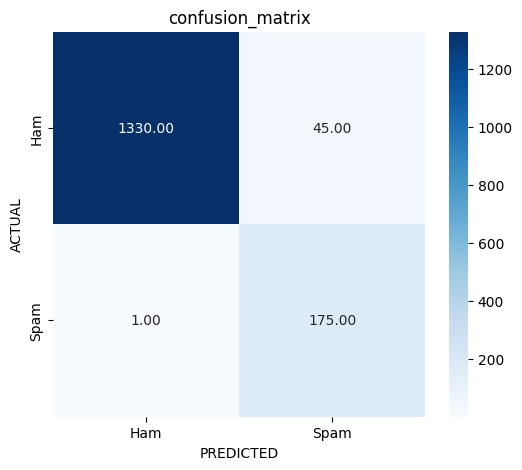

In [97]:
labels = ['Ham', 'Spam']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f',xticklabels=labels, 
            yticklabels=labels)
plt.xlabel("PREDICTED")
plt.ylabel("ACTUAL")
plt.title("confusion_matrix")
plt.show() 